# Conditional GAN — Generator Dataset Sintetis (Generik, untuk Domain Gambar Apa Saja)

Notebook ini melatih **Conditional GAN (cGAN)** dengan *projection discriminator*,
*residual block*, *spectral normalization*, *EMA (Exponential Moving Average)* generator,
dan *classwise feature matching loss* untuk menggenerate citra sintetis dari dataset
bertingkat berikut:

```
dataset/
├── <nama_dataset_1>/
│   ├── <kelas_a>/
│   ├── <kelas_b>/
│   └── ...
├── <nama_dataset_2>/
│   ├── <kelas_a>/
│   └── <kelas_b>/
└── ...
```

Contoh konkret (buah, citra medis, dsb — bebas, tidak harus satu domain):

```
dataset/
├── banana_ripeness/
│   ├── unripe/
│   ├── ripe/
│   └── overripe/
├── cxr/
│   ├── normal/
│   └── pneumonia/
└── retinal_oct/
    ├── class_1/
    └── class_2/
```

**Penting — satu model per dataset/domain:** notebook ini melatih **satu cGAN untuk
satu sub-folder dataset** (dipilih lewat `DATASET_NAME`), bukan menggabungkan semua
domain ke satu model sekaligus. Alasannya, distribusi citra antar domain (foto buah
vs. citra rontgen vs. OCT retina) sangat berbeda secara statistik dan semantik —
mencampurnya ke satu latent space yang sama akan membuat training tidak stabil dan
hasil generate menjadi tidak relevan. Kelas kondisional (`unripe`/`ripe`/...,
`normal`/`pneumonia`, dst.) hanya berlaku **di dalam** domain yang dipilih.

Untuk melatih beberapa domain, jalankan ulang notebook ini dengan mengganti
`DATASET_NAME`, atau gunakan sel terakhir (opsional) untuk melakukan loop otomatis ke
semua domain yang ditemukan.

Channel citra (RGB atau grayscale) dan resolusi **terdeteksi otomatis** dari data —
notebook ini tidak berasumsi semua dataset berwarna 3-channel, sehingga cocok untuk
citra medis grayscale (CXR, OCT) maupun citra alami berwarna (buah, dsb).

> **Catatan untuk domain citra medis (CXR, OCT, dsb.):** citra sintetis hasil GAN
> **tidak boleh** dipakai untuk keperluan diagnosis klinis nyata. Gunakan hanya untuk
> augmentasi data riset/eksperimen model, dan validasikan kualitasnya (misalnya lewat
> FID/KID atau penilaian klinis ahli) sebelum dipakai lebih jauh dalam pipeline
> machine learning.


## 1. Konfigurasi & Import

In [1]:
import os
import math
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.utils as vutils
from PIL import Image
import matplotlib.pyplot as plt


In [2]:
# ============================== KONFIGURASI ==============================
DATASET_ROOT = "./dataset"   # root folder, berisi satu atau lebih sub-folder dataset/domain

# Pilih SATU sub-folder dataset/domain untuk dilatih pada run ini, contoh:
#   "banana_ripeness", "cxr", "retinal_oct"
DATASET_NAME = "banana_ripeness"

OUTPUT_ROOT  = "./dataset_synthetic"          # tempat menyimpan dataset sintetis hasil generate
CKPT_DIR     = f"./checkpoints_cgan/{DATASET_NAME}"
SAMPLE_DIR   = f"./samples_cgan/{DATASET_NAME}"

IMG_SIZE     = 64        # resolusi citra (kuadrat, kelipatan 4, minimal 16)
LATENT_DIM   = 128       # dimensi noise z
# CHANNELS akan terdeteksi otomatis dari data (1 = grayscale, 3 = RGB) pada sel berikutnya

BATCH_SIZE   = 32
EPOCHS       = 50
LR_G         = 2e-4
LR_D         = 2e-4
BETA1, BETA2 = 0.0, 0.9   # umum dipakai pada GAN dengan hinge loss
N_CRITIC     = 1          # jumlah update discriminator per update generator

EMA_DECAY    = 0.999
R1_GAMMA     = 5.0        # bobot R1 gradient penalty pada discriminator (regularisasi)
R1_EVERY     = 16         # terapkan R1 setiap N step (hemat komputasi)
FM_LAMBDA    = 1.0        # bobot classwise feature matching loss

SEED         = 42
FORCE_GPU    = True   # jika True, notebook akan berhenti dengan error jika CUDA tidak terdeteksi
                       # (mencegah training diam-diam jalan di CPU yang jauh lebih lambat)

# PENTING (khusus Windows + Jupyter Notebook): DataLoader dengan num_workers > 0
# memakai multiprocessing 'spawn' di Windows, yang sering HANG TANPA ERROR ketika
# dijalankan di dalam kernel Jupyter (beda dengan Linux/WSL/Colab yang pakai 'fork').
# Akibatnya: training tampak diam ("Training dimulai." muncul lalu tidak ada progres
# sama sekali) dan GPU usage menunjukkan 0% karena belum ada satu batch pun yang
# sempat sampai ke GPU.
#   - Windows + Jupyter Notebook -> NUM_WORKERS = 0 (paling aman, default di sini)
#   - Linux / WSL / Colab / dijalankan sebagai script .py murni -> aman pakai 2-8
NUM_WORKERS = 0

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(SAMPLE_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True   # auto-tune kernel konvolusi, lebih cepat untuk ukuran input tetap
else:
    DEVICE = torch.device("cpu")
    if FORCE_GPU:
        raise RuntimeError(
            "CUDA tidak terdeteksi oleh PyTorch, padahal FORCE_GPU=True.\n"
            "Cek hal berikut:\n"
            "  1. Driver NVIDIA terpasang & 'nvidia-smi' bisa dijalankan di terminal.\n"
            "  2. PyTorch yang terinstall adalah build CUDA, bukan build CPU-only\n"
            "     (install ulang sesuai https://pytorch.org/get-started/locally/).\n"
            "  3. Jika memakai Jupyter remote/Colab, pastikan runtime/kernel sudah\n"
            "     diset ke GPU.\n"
            "Set FORCE_GPU=False di sel ini jika memang sengaja ingin jalan di CPU."
        )

print("Device terpakai     :", DEVICE)
if DEVICE.type == "cuda":
    idx = torch.cuda.current_device()
    print("Nama GPU            :", torch.cuda.get_device_name(idx))
    total_mem_gb = torch.cuda.get_device_properties(idx).total_memory / (1024 ** 3)
    print(f"Total VRAM           : {total_mem_gb:.1f} GB")
    print("CUDA version (build) :", torch.version.cuda)
else:
    print("PERINGATAN: training berjalan di CPU, akan jauh lebih lambat.")

print("NUM_WORKERS (DataLoader):", NUM_WORKERS)


Device terpakai     : cuda
Nama GPU            : NVIDIA GeForce RTX 4070 SUPER
Total VRAM           : 12.0 GB
CUDA version (build) : 12.8
NUM_WORKERS (DataLoader): 0


## 2. Cek Dataset/Domain yang Tersedia

Menampilkan semua sub-folder domain yang ditemukan di `DATASET_ROOT`, beserta
kelas-kelas (sub-folder level berikutnya) di masing-masing domain. Berguna untuk
memastikan `DATASET_NAME` di sel konfigurasi sudah benar sebelum lanjut.

In [3]:
root = Path(DATASET_ROOT)
available_domains = sorted([d.name for d in root.iterdir() if d.is_dir()])

print("Domain dataset yang ditemukan di", DATASET_ROOT, ":")
for d in available_domains:
    classes_in_domain = sorted([c.name for c in (root / d).iterdir() if c.is_dir()])
    print(f"  - {d}: {classes_in_domain}")

assert DATASET_NAME in available_domains, (
    f"DATASET_NAME='{DATASET_NAME}' tidak ditemukan. Pilih salah satu dari: {available_domains}"
)
print(f"\nDomain terpilih untuk training: '{DATASET_NAME}'")


Domain dataset yang ditemukan di ./dataset :
  - banana_ripeness: ['overripe', 'ripe', 'rotten', 'unripe']
  - retinal_oct: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']

Domain terpilih untuk training: 'banana_ripeness'


## 3. Dataset Loader (generik — bekerja untuk domain citra apa pun)

`ImageClassDataset` melakukan scan pada `DATASET_ROOT/DATASET_NAME/<kelas>/*.{ext}`
dan memetakan setiap sub-folder kelas menjadi satu label kondisional. Jumlah channel
citra (1=grayscale, 3=RGB) dideteksi otomatis dari sampel pertama, sehingga notebook
yang sama bisa dipakai untuk foto buah berwarna maupun citra medis grayscale tanpa
diubah manual.

In [4]:
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff")

def detect_channels(domain_dir):
    """Deteksi jumlah channel (1 atau 3) dari citra pertama yang ditemukan di domain_dir."""
    for class_dir in sorted(Path(domain_dir).iterdir()):
        if not class_dir.is_dir():
            continue
        for f in class_dir.iterdir():
            if f.suffix.lower() in IMG_EXTS:
                with Image.open(f) as img:
                    mode = img.convert("RGB").convert(img.mode).mode
                    img_rgb = img.convert("RGB")
                    # cek apakah ketiga channel identik (indikasi grayscale yang disimpan sebagai RGB)
                    arr = np.array(img_rgb)
                    if arr.ndim == 2:
                        return 1
                    if arr.shape[-1] == 3 and np.array_equal(arr[..., 0], arr[..., 1]) and np.array_equal(arr[..., 1], arr[..., 2]):
                        return 1
                    return 3
    raise FileNotFoundError(f"Tidak ada citra ditemukan di {domain_dir}")


class ImageClassDataset(Dataset):
    """Dataset generik 1-level di bawah domain terpilih:
    DATASET_ROOT/DATASET_NAME/<kelas>/gambar.*

    Bekerja untuk domain citra apa pun (buah, citra medis, dsb.) karena hanya
    bergantung pada struktur folder, bukan jenis konten citra.
    """

    def __init__(self, domain_root, img_size=64, channels=3, transform=None):
        self.domain_root = Path(domain_root)
        self.channels = channels
        self.classes = sorted([d.name for d in self.domain_root.iterdir() if d.is_dir()])
        if len(self.classes) == 0:
            raise FileNotFoundError(f"Tidak ada sub-folder kelas ditemukan di {domain_root}")

        self.samples = []
        for idx, cls_name in enumerate(self.classes):
            cls_dir = self.domain_root / cls_name
            files = [f for f in cls_dir.iterdir() if f.is_file() and f.suffix.lower() in IMG_EXTS]
            for f in files:
                self.samples.append((str(f), idx))

        if len(self.samples) == 0:
            raise FileNotFoundError(f"Tidak ada file gambar ditemukan di {domain_root}")

        self.num_classes = len(self.classes)

        norm_mean = [0.5] * channels
        norm_std = [0.5] * channels
        self.transform = transform or T.Compose([
            T.Resize((img_size, img_size)),
            T.RandomHorizontalFlip(p=0.5),
            T.ToTensor(),
            T.Normalize(norm_mean, norm_std),  # rentang [-1, 1], sesuai output tanh generator
        ])

        self.counts = defaultdict(int)
        for _, lbl in self.samples:
            self.counts[self.classes[lbl]] += 1

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        mode = "L" if self.channels == 1 else "RGB"
        img = Image.open(path).convert(mode)
        img = self.transform(img)
        return img, label


domain_dir = root / DATASET_NAME
CHANNELS = detect_channels(domain_dir)
print(f"Channel citra terdeteksi: {CHANNELS} ({'grayscale' if CHANNELS == 1 else 'RGB'})")

dataset = ImageClassDataset(domain_dir, img_size=IMG_SIZE, channels=CHANNELS)
NUM_CLASSES = dataset.num_classes

print(f"Domain             : {DATASET_NAME}")
print(f"Total citra        : {len(dataset)}")
print(f"Jumlah kelas        : {NUM_CLASSES} -> {dataset.classes}")
print("Distribusi per kelas:")
for cls_name, cnt in dataset.counts.items():
    print(f"  - {cls_name:20s}: {cnt} citra")

dataloader = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, drop_last=True, pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
)


Channel citra terdeteksi: 3 (RGB)
Domain             : banana_ripeness
Total citra        : 13478
Jumlah kelas        : 4 -> ['overripe', 'ripe', 'rotten', 'unripe']
Distribusi per kelas:
  - overripe            : 2691 citra
  - ripe                : 4015 citra
  - rotten              : 4593 citra
  - unripe              : 2179 citra


## 4. Komponen Arsitektur — Residual Block (Generator & Discriminator)

In [5]:
class ConditionalBatchNorm2d(nn.Module):
    """BatchNorm dengan parameter gain/bias yang dimodulasi oleh embedding label (class-conditional BN)."""

    def __init__(self, num_features, num_classes):
        super().__init__()
        self.num_features = num_features
        self.bn = nn.BatchNorm2d(num_features, affine=False)
        self.embed_gamma = nn.Embedding(num_classes, num_features)
        self.embed_beta = nn.Embedding(num_classes, num_features)
        nn.init.ones_(self.embed_gamma.weight)
        nn.init.zeros_(self.embed_beta.weight)

    def forward(self, x, y):
        out = self.bn(x)
        gamma = self.embed_gamma(y).view(-1, self.num_features, 1, 1)
        beta = self.embed_beta(y).view(-1, self.num_features, 1, 1)
        return out * gamma + beta


class ResBlockUp(nn.Module):
    """Residual block dengan upsampling (untuk Generator), conditional via class-conditional BatchNorm."""

    def __init__(self, in_ch, out_ch, num_classes):
        super().__init__()
        self.bn1 = ConditionalBatchNorm2d(in_ch, num_classes)
        self.bn2 = ConditionalBatchNorm2d(out_ch, num_classes)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.learnable_sc = in_ch != out_ch
        if self.learnable_sc:
            self.conv_sc = nn.Conv2d(in_ch, out_ch, 1)
        self.act = nn.ReLU(inplace=True)

    def _upsample(self, x):
        return F.interpolate(x, scale_factor=2, mode="nearest")

    def forward(self, x, y):
        h = self.act(self.bn1(x, y))
        h = self._upsample(h)
        h = self.conv1(h)
        h = self.act(self.bn2(h, y))
        h = self.conv2(h)

        sc = self._upsample(x)
        if self.learnable_sc:
            sc = self.conv_sc(sc)
        return h + sc


class ResBlockDown(nn.Module):
    """Residual block dengan downsampling (untuk Discriminator), pakai spectral norm."""

    def __init__(self, in_ch, out_ch, downsample=True):
        super().__init__()
        self.conv1 = nn.utils.spectral_norm(nn.Conv2d(in_ch, out_ch, 3, padding=1))
        self.conv2 = nn.utils.spectral_norm(nn.Conv2d(out_ch, out_ch, 3, padding=1))
        self.downsample = downsample
        self.learnable_sc = (in_ch != out_ch) or downsample
        if self.learnable_sc:
            self.conv_sc = nn.utils.spectral_norm(nn.Conv2d(in_ch, out_ch, 1))
        self.act = nn.LeakyReLU(0.2, inplace=False)

    def forward(self, x):
        h = self.act(x)
        h = self.conv1(h)
        h = self.act(h)
        h = self.conv2(h)
        if self.downsample:
            h = F.avg_pool2d(h, 2)

        sc = x
        if self.learnable_sc:
            sc = self.conv_sc(sc)
        if self.downsample:
            sc = F.avg_pool2d(sc, 2)
        return h + sc


## 5. Generator & Discriminator (Conditional, Projection Discriminator)

Nama kelas dibuat generik (`ConditionalGenerator` / `ConditionalDiscriminator`) dan
parameter `channels` mengikuti hasil deteksi otomatis (1 atau 3), sehingga arsitektur
yang sama dipakai apa pun domain citranya.

In [6]:
class ConditionalGenerator(nn.Module):
    """Generator berbasis residual block + class-conditional BatchNorm.
    Jumlah upsampling block menyesuaikan IMG_SIZE secara otomatis (log2(IMG_SIZE/4))."""

    def __init__(self, latent_dim, num_classes, img_size=64, base_ch=64, channels=3):
        super().__init__()
        self.init_size = 4
        n_upsample = int(math.log2(img_size / self.init_size))
        assert img_size % self.init_size == 0 and n_upsample >= 2, \
            "IMG_SIZE harus kelipatan 4 dan >= 16"

        mults = [min(8, 2 ** i) for i in reversed(range(n_upsample))]
        self.fc = nn.Linear(latent_dim, base_ch * mults[0] * self.init_size * self.init_size)
        self.init_ch = base_ch * mults[0]

        blocks = []
        in_ch = self.init_ch
        for i in range(n_upsample):
            out_ch = base_ch * (mults[i + 1] if i + 1 < len(mults) else 1)
            blocks.append(ResBlockUp(in_ch, out_ch, num_classes))
            in_ch = out_ch
        self.blocks = nn.ModuleList(blocks)

        self.final_bn = nn.BatchNorm2d(in_ch)
        self.final_conv = nn.Conv2d(in_ch, channels, 3, padding=1)
        self.act = nn.ReLU(inplace=True)

    def forward(self, z, y, return_features=False):
        h = self.fc(z).view(z.size(0), self.init_ch, self.init_size, self.init_size)
        feats = []
        for block in self.blocks:
            h = block(h, y)
            feats.append(h)
        h = self.act(self.final_bn(h))
        img = torch.tanh(self.final_conv(h))
        if return_features:
            return img, feats
        return img


class ConditionalDiscriminator(nn.Module):
    """Projection Discriminator (Miyato et al. 2018): skor = D_feature(x) + <embed(y), feature(x)>.
    Memberikan sinyal kondisional yang lebih kuat dibanding concat label naif."""

    def __init__(self, num_classes, img_size=64, base_ch=64, channels=3):
        super().__init__()
        n_downsample = int(math.log2(img_size / 4))
        mults = [min(8, 2 ** i) for i in range(n_downsample)]

        blocks = []
        in_ch = channels
        for i in range(n_downsample):
            out_ch = base_ch * mults[i]
            blocks.append(ResBlockDown(in_ch, out_ch, downsample=True))
            in_ch = out_ch
        self.blocks = nn.ModuleList(blocks)
        self.feat_ch = in_ch

        self.linear = nn.utils.spectral_norm(nn.Linear(in_ch, 1))
        self.embed = nn.utils.spectral_norm(nn.Embedding(num_classes, in_ch))
        self.act = nn.LeakyReLU(0.2, inplace=False)

    def forward(self, x, y, return_features=False):
        h = x
        feats = []
        for block in self.blocks:
            h = block(h)
            feats.append(h)
        h = self.act(h)
        h = torch.sum(h, dim=(2, 3))  # global sum pooling

        out = self.linear(h)
        out = out + torch.sum(self.embed(y) * h, dim=1, keepdim=True)
        if return_features:
            return out.squeeze(1), feats
        return out.squeeze(1)


## 6. EMA Generator & Loss Function

- **Hinge loss** untuk adversarial training (stabil untuk GAN dengan spectral norm).
- **R1 gradient penalty** pada discriminator (regularisasi terhadap data nyata).
- **Classwise feature matching loss**: menyamakan rata-rata fitur discriminator
  citra sintetis dengan rata-rata fitur citra nyata, dihitung *per kelas* (bukan
  rata-rata global), supaya setiap kelas belajar distribusi fitur miliknya sendiri.
- **EMA generator**: salinan bobot generator yang diperbarui secara exponential
  moving average, dipakai khusus saat *inference* (lebih stabil dibanding generator
  hasil training langsung).

In [7]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.clone().detach() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if v.dtype.is_floating_point:
                self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1 - self.decay)
            else:
                self.shadow[k] = v.clone()

    def copy_to(self, model):
        model.load_state_dict(self.shadow, strict=True)


def hinge_loss_dis(real_logits, fake_logits):
    loss_real = torch.mean(F.relu(1.0 - real_logits))
    loss_fake = torch.mean(F.relu(1.0 + fake_logits))
    return loss_real + loss_fake


def hinge_loss_gen(fake_logits):
    return -torch.mean(fake_logits)


def r1_penalty(discriminator, real_imgs, real_labels):
    real_imgs = real_imgs.clone().requires_grad_(True)
    real_logits = discriminator(real_imgs, real_labels)
    grad = torch.autograd.grad(
        outputs=real_logits.sum(), inputs=real_imgs,
        create_graph=True, retain_graph=True,
    )[0]
    penalty = grad.pow(2).reshape(grad.size(0), -1).sum(1).mean()
    return penalty


def classwise_feature_matching_loss(real_feats, fake_feats, labels, num_classes):
    """Hitung MSE antara rata-rata fitur (level terakhir) real vs fake, per kelas."""
    loss = 0.0
    n_used = 0
    real_last = real_feats[-1].mean(dim=(2, 3))   # (B, C)
    fake_last = fake_feats[-1].mean(dim=(2, 3))   # (B, C)
    for c in range(num_classes):
        mask = labels == c
        if mask.sum() == 0:
            continue
        real_mean = real_last[mask].mean(dim=0)
        fake_mean = fake_last[mask].mean(dim=0)
        loss = loss + F.mse_loss(fake_mean, real_mean)
        n_used += 1
    if n_used == 0:
        return torch.tensor(0.0, device=real_last.device)
    return loss / n_used


## 7. Inisialisasi Model, Optimizer, EMA

In [8]:
G = ConditionalGenerator(LATENT_DIM, NUM_CLASSES, img_size=IMG_SIZE, channels=CHANNELS).to(DEVICE)
D = ConditionalDiscriminator(NUM_CLASSES, img_size=IMG_SIZE, channels=CHANNELS).to(DEVICE)

opt_G = torch.optim.Adam(G.parameters(), lr=LR_G, betas=(BETA1, BETA2))
opt_D = torch.optim.Adam(D.parameters(), lr=LR_D, betas=(BETA1, BETA2))

ema = EMA(G, decay=EMA_DECAY)
G_ema = ConditionalGenerator(LATENT_DIM, NUM_CLASSES, img_size=IMG_SIZE, channels=CHANNELS).to(DEVICE)
G_ema.load_state_dict(G.state_dict())
G_ema.eval()

print(G)
print(D)
n_params_g = sum(p.numel() for p in G.parameters())
n_params_d = sum(p.numel() for p in D.parameters())
print(f"Jumlah parameter Generator     : {n_params_g:,}")
print(f"Jumlah parameter Discriminator : {n_params_d:,}")


ConditionalGenerator(
  (fc): Linear(in_features=128, out_features=8192, bias=True)
  (blocks): ModuleList(
    (0): ResBlockUp(
      (bn1): ConditionalBatchNorm2d(
        (bn): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        (embed_gamma): Embedding(4, 512)
        (embed_beta): Embedding(4, 512)
      )
      (bn2): ConditionalBatchNorm2d(
        (bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        (embed_gamma): Embedding(4, 256)
        (embed_beta): Embedding(4, 256)
      )
      (conv1): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv_sc): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
      (act): ReLU(inplace=True)
    )
    (1): ResBlockUp(
      (bn1): ConditionalBatchNorm2d(
        (bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)


In [9]:
# Verifikasi tambahan: pastikan parameter model benar-benar berada di GPU
g_device = next(G.parameters()).device
d_device = next(D.parameters()).device
print(f"Parameter Generator ada di      : {g_device}")
print(f"Parameter Discriminator ada di  : {d_device}")
assert g_device.type == DEVICE.type and d_device.type == DEVICE.type, \
    "Model tidak berada di device yang diharapkan, cek ulang konfigurasi DEVICE."

if DEVICE.type == "cuda":
    torch.cuda.synchronize()
    allocated_mb = torch.cuda.memory_allocated() / (1024 ** 2)
    reserved_mb = torch.cuda.memory_reserved() / (1024 ** 2)
    print(f"VRAM teralokasi (model)         : {allocated_mb:.1f} MB")
    print(f"VRAM tercadangkan (cache)       : {reserved_mb:.1f} MB")
print("Model siap dilatih di:", DEVICE)


Parameter Generator ada di      : cuda:0
Parameter Discriminator ada di  : cuda:0
VRAM teralokasi (model)         : 60.8 MB
VRAM tercadangkan (cache)       : 68.0 MB
Model siap dilatih di: cuda


## 8. Training Loop

Setiap step:
1. Update Discriminator (hinge loss + R1 penalty berkala) pada citra nyata vs sintetis.
2. Update Generator (hinge loss + classwise feature matching loss) agar fitur citra
   sintetis menyerupai fitur citra nyata *per kelas*.
3. Update EMA generator.

Sampel pratinjau (grid per kelas) disimpan tiap `SAMPLE_EVERY` epoch ke `SAMPLE_DIR`.


In [10]:
SAMPLE_EVERY = 10
LOG_EVERY    = 50
CKPT_EVERY   = 50

N_PREVIEW_PER_CLASS = 8
fixed_z = torch.randn(NUM_CLASSES * N_PREVIEW_PER_CLASS, LATENT_DIM, device=DEVICE)
fixed_y = torch.arange(NUM_CLASSES, device=DEVICE).repeat_interleave(N_PREVIEW_PER_CLASS)

global_step = 0
history = {"d_loss": [], "g_loss": [], "fm_loss": []}

for epoch in range(1, EPOCHS + 1):
    for real_imgs, labels in dataloader:
        real_imgs = real_imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        bs = real_imgs.size(0)

        # ---------------------- Update Discriminator ----------------------
        for _ in range(N_CRITIC):
            z = torch.randn(bs, LATENT_DIM, device=DEVICE)
            fake_imgs = G(z, labels).detach()

            real_logits = D(real_imgs, labels)
            fake_logits = D(fake_imgs, labels)
            d_loss = hinge_loss_dis(real_logits, fake_logits)

            if global_step % R1_EVERY == 0:
                r1 = r1_penalty(D, real_imgs, labels)
                d_loss = d_loss + (R1_GAMMA / 2) * r1

            opt_D.zero_grad(set_to_none=True)
            d_loss.backward()
            opt_D.step()

        # ------------------------ Update Generator -------------------------
        z = torch.randn(bs, LATENT_DIM, device=DEVICE)
        fake_imgs = G(z, labels)
        fake_logits, fake_feats = D(fake_imgs, labels, return_features=True)
        with torch.no_grad():
            _, real_feats = D(real_imgs, labels, return_features=True)

        g_adv_loss = hinge_loss_gen(fake_logits)
        fm_loss = classwise_feature_matching_loss(real_feats, fake_feats, labels, NUM_CLASSES)
        g_loss = g_adv_loss + FM_LAMBDA * fm_loss

        opt_G.zero_grad(set_to_none=True)
        g_loss.backward()
        opt_G.step()

        ema.update(G)
        global_step += 1

        if global_step % LOG_EVERY == 0:
            history["d_loss"].append(d_loss.item())
            history["g_loss"].append(g_loss.item())
            history["fm_loss"].append(fm_loss.item())

    print(f"Epoch [{epoch}/{EPOCHS}] D_loss={d_loss.item():.4f} "
          f"G_loss={g_loss.item():.4f} FM_loss={fm_loss.item():.4f}")

    if epoch % SAMPLE_EVERY == 0 or epoch == 1:
        ema.copy_to(G_ema)
        G_ema.eval()
        with torch.no_grad():
            samples = G_ema(fixed_z, fixed_y).cpu()
        grid = vutils.make_grid(
            samples, nrow=N_PREVIEW_PER_CLASS, normalize=True, value_range=(-1, 1)
        )
        plt.figure(figsize=(12, 6))
        plt.axis("off")
        plt.title(f"[{DATASET_NAME}] Epoch {epoch} — baris = kelas {dataset.classes}")
        cmap = "gray" if CHANNELS == 1 else None
        grid_np = grid.permute(1, 2, 0).numpy()
        plt.imshow(grid_np.squeeze() if CHANNELS == 1 else grid_np, cmap=cmap)
        plt.savefig(f"{SAMPLE_DIR}/epoch_{epoch:04d}.png", bbox_inches="tight")
        plt.close()

    if epoch % CKPT_EVERY == 0 or epoch == EPOCHS:
        torch.save({
            "G": G.state_dict(),
            "G_ema": ema.shadow,
            "D": D.state_dict(),
            "opt_G": opt_G.state_dict(),
            "opt_D": opt_D.state_dict(),
            "epoch": epoch,
            "dataset_name": DATASET_NAME,
            "classes": dataset.classes,
            "channels": CHANNELS,
            "img_size": IMG_SIZE,
        }, f"{CKPT_DIR}/cgan_epoch_{epoch:04d}.pt")

print("Training selesai.")


Epoch [1/50] D_loss=1.9284 G_loss=0.3915 FM_loss=0.0000
Epoch [2/50] D_loss=1.9853 G_loss=0.2555 FM_loss=0.0000
Epoch [3/50] D_loss=2.0226 G_loss=0.5811 FM_loss=0.0000
Epoch [4/50] D_loss=1.9519 G_loss=0.2997 FM_loss=0.0000
Epoch [5/50] D_loss=1.9284 G_loss=-0.1872 FM_loss=0.0000
Epoch [6/50] D_loss=1.9934 G_loss=0.4167 FM_loss=0.0000
Epoch [7/50] D_loss=2.0472 G_loss=-0.1832 FM_loss=0.0000
Epoch [8/50] D_loss=1.9101 G_loss=-0.3473 FM_loss=0.0000
Epoch [9/50] D_loss=2.0038 G_loss=0.1578 FM_loss=0.0000
Epoch [10/50] D_loss=2.0493 G_loss=0.0246 FM_loss=0.0000
Epoch [11/50] D_loss=2.0776 G_loss=0.0811 FM_loss=0.0000
Epoch [12/50] D_loss=1.9713 G_loss=0.0702 FM_loss=0.0000
Epoch [13/50] D_loss=1.9531 G_loss=0.2381 FM_loss=0.0000
Epoch [14/50] D_loss=1.8764 G_loss=0.1100 FM_loss=0.0000
Epoch [15/50] D_loss=2.0126 G_loss=-0.1443 FM_loss=0.0000
Epoch [16/50] D_loss=1.9597 G_loss=0.3792 FM_loss=0.0000
Epoch [17/50] D_loss=1.9338 G_loss=-0.1272 FM_loss=0.0001
Epoch [18/50] D_loss=1.8937 G_loss=

## 9. Kurva Loss Training

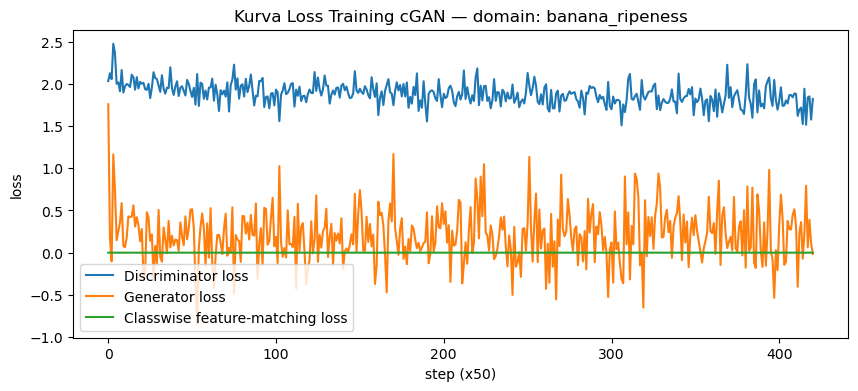

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(history["d_loss"], label="Discriminator loss")
plt.plot(history["g_loss"], label="Generator loss")
plt.plot(history["fm_loss"], label="Classwise feature-matching loss")
plt.xlabel(f"step (x{LOG_EVERY})")
plt.ylabel("loss")
plt.legend()
plt.title(f"Kurva Loss Training cGAN — domain: {DATASET_NAME}")
plt.show()


## 10. Load Checkpoint (opsional)

Jalankan sel ini jika ingin melanjutkan dari checkpoint tersimpan tanpa training ulang
dari awal — cukup ubah `CKPT_PATH`. Checkpoint juga menyimpan `dataset_name`,
`channels`, dan `img_size` sehingga bisa dicek kecocokannya sebelum dimuat.

In [12]:
CKPT_PATH = None  # contoh: f"{CKPT_DIR}/cgan_epoch_0500.pt"

if CKPT_PATH is not None and os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    assert ckpt["dataset_name"] == DATASET_NAME, (
        f"Checkpoint dilatih untuk domain '{ckpt['dataset_name']}', "
        f"bukan '{DATASET_NAME}' yang sedang aktif."
    )
    G.load_state_dict(ckpt["G"])
    D.load_state_dict(ckpt["D"])
    ema.shadow = ckpt["G_ema"]
    ema.copy_to(G_ema)
    G_ema.eval()
    print(f"Checkpoint dimuat dari epoch {ckpt['epoch']} (domain: {ckpt['dataset_name']})")
else:
    print("Tidak memuat checkpoint, memakai bobot model saat ini di memori.")


Tidak memuat checkpoint, memakai bobot model saat ini di memori.


## 11. Ekspor Dataset Sintetis

Menggenerate citra sintetis menggunakan **G_ema** (lebih stabil) untuk setiap kelas,
lalu menyimpannya ke struktur folder yang identik dengan domain asli:

```
dataset_synthetic/
└── <DATASET_NAME>/
    ├── <kelas_a>/   (citra sintetis_*.png/tif)
    └── <kelas_b>/
```


In [13]:
N_SYNTH_PER_CLASS = 200  # jumlah citra sintetis yang digenerate per kelas
GEN_BATCH = 32

def tensor_to_image(img_tensor, channels):
    """Konversi tensor [-1, 1] -> PIL Image (RGB atau L, sesuai jumlah channel)."""
    img = (img_tensor.clamp(-1, 1) + 1) / 2.0
    arr = (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    if channels == 1:
        return Image.fromarray(arr.squeeze(-1), mode="L")
    return Image.fromarray(arr, mode="RGB")


@torch.no_grad()
def export_synthetic_dataset(generator, classes, dataset_name, output_root, channels,
                              n_per_class=200, batch_size=32, latent_dim=128):
    generator.eval()
    base_out = Path(output_root) / dataset_name
    base_out.mkdir(parents=True, exist_ok=True)

    for class_idx, class_name in enumerate(classes):
        out_dir = base_out / class_name
        out_dir.mkdir(parents=True, exist_ok=True)

        n_generated = 0
        while n_generated < n_per_class:
            cur_bs = min(batch_size, n_per_class - n_generated)
            z = torch.randn(cur_bs, latent_dim, device=DEVICE)
            y = torch.full((cur_bs,), class_idx, dtype=torch.long, device=DEVICE)
            fake = generator(z, y).cpu()

            for i in range(cur_bs):
                img = tensor_to_image(fake[i], channels)
                fname = f"synthetic_{class_name}_{n_generated + i:05d}.png"
                img.save(out_dir / fname)
            n_generated += cur_bs

        print(f"[{dataset_name}/{class_name}] {n_generated} citra sintetis disimpan -> {out_dir}")


export_synthetic_dataset(
    G_ema, dataset.classes, DATASET_NAME, OUTPUT_ROOT, CHANNELS,
    n_per_class=N_SYNTH_PER_CLASS, batch_size=GEN_BATCH, latent_dim=LATENT_DIM,
)

print("\nSelesai. Dataset sintetis tersimpan di:", Path(OUTPUT_ROOT) / DATASET_NAME)


[banana_ripeness/overripe] 200 citra sintetis disimpan -> dataset_synthetic\banana_ripeness\overripe
[banana_ripeness/ripe] 200 citra sintetis disimpan -> dataset_synthetic\banana_ripeness\ripe
[banana_ripeness/rotten] 200 citra sintetis disimpan -> dataset_synthetic\banana_ripeness\rotten
[banana_ripeness/unripe] 200 citra sintetis disimpan -> dataset_synthetic\banana_ripeness\unripe

Selesai. Dataset sintetis tersimpan di: dataset_synthetic\banana_ripeness


## 12. Pratinjau Cepat Hasil Ekspor

Menampilkan beberapa contoh citra sintetis dari setiap kelas pada domain yang baru
dilatih, untuk pemeriksaan visual kualitas hasil generate.

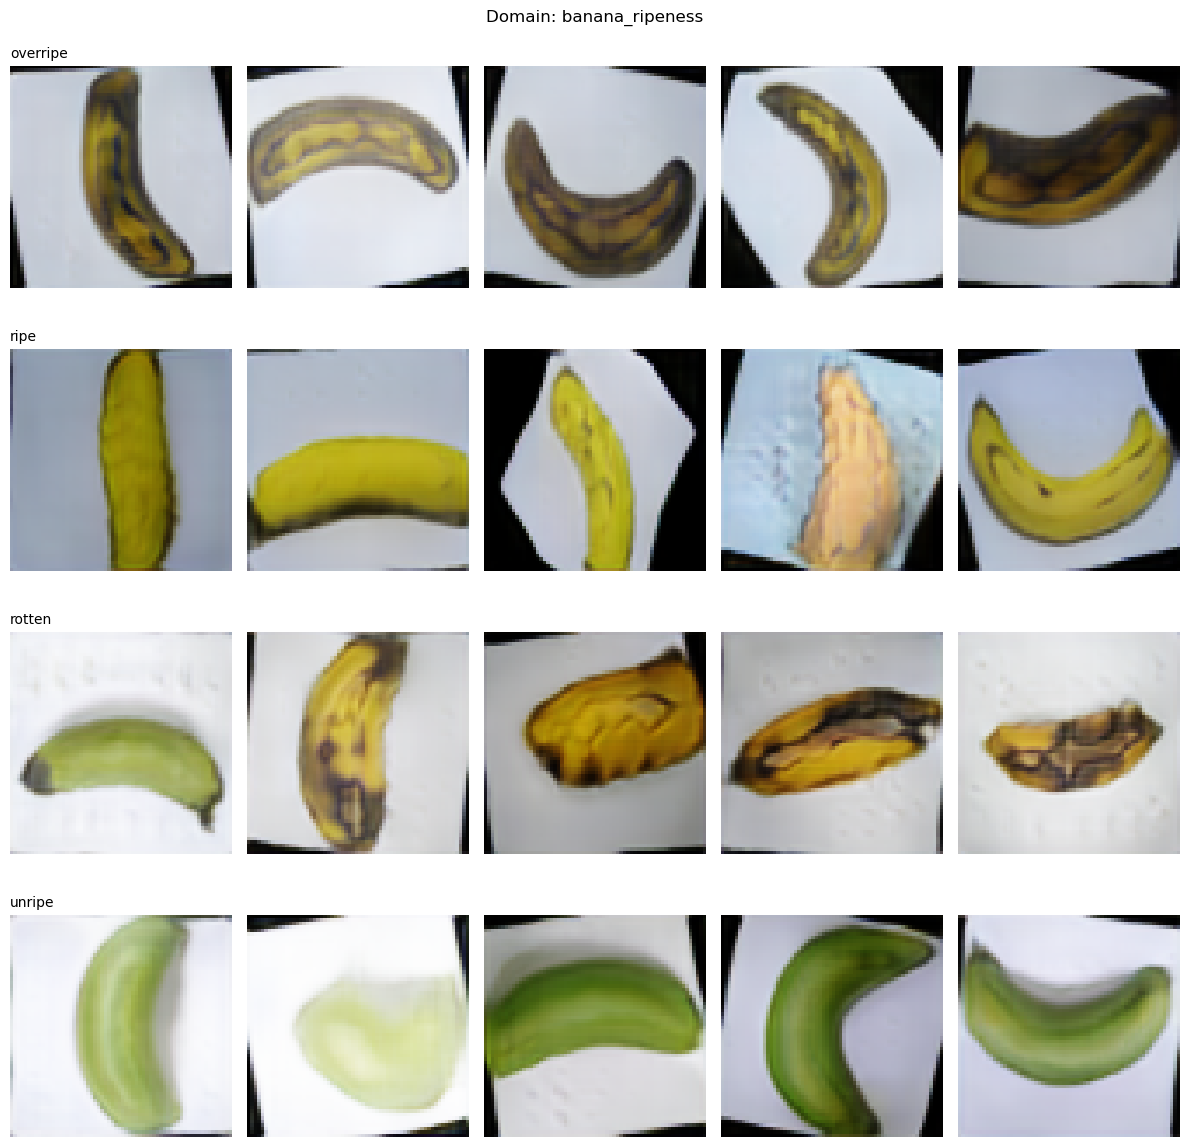

In [14]:
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(12, 3 * NUM_CLASSES))
cmap = "gray" if CHANNELS == 1 else None
for class_idx, class_name in enumerate(dataset.classes):
    sample_dir = Path(OUTPUT_ROOT) / DATASET_NAME / class_name
    files = sorted(sample_dir.glob("*.png"))[:5]
    for col, f in enumerate(files):
        ax = axes[class_idx, col] if NUM_CLASSES > 1 else axes[col]
        ax.imshow(Image.open(f), cmap=cmap)
        ax.axis("off")
        if col == 0:
            ax.set_title(class_name, fontsize=10, loc="left")
plt.suptitle(f"Domain: {DATASET_NAME}")
plt.tight_layout()
plt.show()


## 13. (Opsional) Loop Otomatis ke Semua Domain

Jalankan sel ini hanya jika ingin melatih ulang notebook secara terprogram untuk
**setiap** domain yang ditemukan di `DATASET_ROOT`, satu per satu, masing-masing
menyimpan checkpoint, sampel, dan ekspor sintetis ke folder terpisah berdasarkan
nama domainnya. Karena ini membungkus ulang langkah-langkah di atas dalam satu
fungsi, sel ini bersifat mandiri (tidak mengubah variabel global di atas) dan aman
dijalankan setelah training manual selesai, sebagai cara cepat memproses domain
lain dengan konfigurasi (epoch, ukuran, dsb.) yang sama.

> Untuk dataset besar/banyak domain, pertimbangkan menjalankan tiap domain secara
> terpisah (script `.py`) alih-alih satu notebook panjang, agar lebih mudah
> dipantau dan di-resume jika terhenti.

In [15]:
RUN_ALL_DOMAINS = False  # ubah ke True untuk menjalankan loop semua domain

def train_one_domain(domain_name, epochs=100, img_size=64, batch_size=32):
    """Versi ringkas dari pipeline training+ekspor di atas, untuk satu domain.
    Fungsi ini sengaja memakai variabel lokal agar tidak bertabrakan dengan
    variabel global hasil training manual di sel-sel sebelumnya."""
    domain_path = root / domain_name
    ch = detect_channels(domain_path)
    ds = ImageClassDataset(domain_path, img_size=img_size, channels=ch)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS,
                     drop_last=True, persistent_workers=(NUM_WORKERS > 0))

    g = ConditionalGenerator(LATENT_DIM, ds.num_classes, img_size=img_size, channels=ch).to(DEVICE)
    d = ConditionalDiscriminator(ds.num_classes, img_size=img_size, channels=ch).to(DEVICE)
    og = torch.optim.Adam(g.parameters(), lr=LR_G, betas=(BETA1, BETA2))
    od = torch.optim.Adam(d.parameters(), lr=LR_D, betas=(BETA1, BETA2))
    ema_local = EMA(g, decay=EMA_DECAY)

    step = 0
    for ep in range(1, epochs + 1):
        for imgs, labels in dl:
            imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            bs = imgs.size(0)

            z = torch.randn(bs, LATENT_DIM, device=DEVICE)
            fake = g(z, labels).detach()
            d_loss = hinge_loss_dis(d(imgs, labels), d(fake, labels))
            if step % R1_EVERY == 0:
                d_loss = d_loss + (R1_GAMMA / 2) * r1_penalty(d, imgs, labels)
            od.zero_grad(set_to_none=True); d_loss.backward(); od.step()

            z = torch.randn(bs, LATENT_DIM, device=DEVICE)
            fake = g(z, labels)
            fake_logits, fake_feats = d(fake, labels, return_features=True)
            with torch.no_grad():
                _, real_feats = d(imgs, labels, return_features=True)
            g_loss = hinge_loss_gen(fake_logits) + FM_LAMBDA * classwise_feature_matching_loss(
                real_feats, fake_feats, labels, ds.num_classes
            )
            og.zero_grad(set_to_none=True); g_loss.backward(); og.step()
            ema_local.update(g)
            step += 1
        if ep % 20 == 0 or ep == epochs:
            print(f"  [{domain_name}] epoch {ep}/{epochs} D={d_loss.item():.3f} G={g_loss.item():.3f}")

    g_ema_local = ConditionalGenerator(LATENT_DIM, ds.num_classes, img_size=img_size, channels=ch).to(DEVICE)
    ema_local.copy_to(g_ema_local)
    g_ema_local.eval()

    export_synthetic_dataset(
        g_ema_local, ds.classes, domain_name, OUTPUT_ROOT, ch,
        n_per_class=N_SYNTH_PER_CLASS, batch_size=GEN_BATCH, latent_dim=LATENT_DIM,
    )
    return g_ema_local, ds


if RUN_ALL_DOMAINS:
    for domain_name in available_domains:
        print(f"\n=== Melatih domain: {domain_name} ===")
        train_one_domain(domain_name, epochs=EPOCHS, img_size=IMG_SIZE, batch_size=BATCH_SIZE)


## Catatan & Tips Penyesuaian

- **Berlaku untuk domain citra apa pun**: arsitektur (`ConditionalGenerator` /
  `ConditionalDiscriminator`), loader (`ImageClassDataset`), dan loss tidak
  mengandung asumsi spesifik domain — hanya bergantung pada struktur folder dan
  jumlah channel yang terdeteksi otomatis. Cukup ganti `DATASET_NAME` untuk pindah
  ke domain lain (buah, citra medis, tekstur industri, dsb).
- **Dataset kecil/tidak seimbang** (umum pada data medis, mis. kelas `pneumonia`
  jauh lebih banyak dari `normal`, atau sebaliknya): pertimbangkan augmentasi
  tambahan ringan di `transform`, atau *weighted sampling* pada `DataLoader` supaya
  tiap kelas mendapat representasi setara saat training.
- **Resolusi lebih tinggi**: ubah `IMG_SIZE` ke 128/256 — generator/discriminator
  otomatis menambah jumlah block (`log2(IMG_SIZE/4)`). Turunkan `BATCH_SIZE` jika
  terjadi OOM, terutama untuk citra grayscale resolusi tinggi seperti CXR/OCT.
- **Mode collapse**: jika sampel antar kelas mulai mirip, naikkan `FM_LAMBDA` atau
  turunkan `N_CRITIC`. R1 penalty (`R1_GAMMA`) juga membantu stabilitas.
- **Domain citra medis**: selalu cantumkan disclaimer bahwa citra sintetis hanya
  untuk augmentasi riset/eksperimen, bukan untuk diagnosis nyata. Pertimbangkan
  juga isu etik/regulasi (mis. IRB, lisensi dataset) sebelum mempublikasikan hasil
  yang melibatkan citra medis sintetis.
- **Evaluasi kuantitatif**: untuk laporan WoS Q1/Q2, pertimbangkan menambahkan
  metrik FID/KID per kelas (membandingkan distribusi fitur Inception antara citra
  asli dan sintetis) sebagai sel evaluasi tambahan jika diperlukan.
